Entorno listo 
Árbol entrenado 


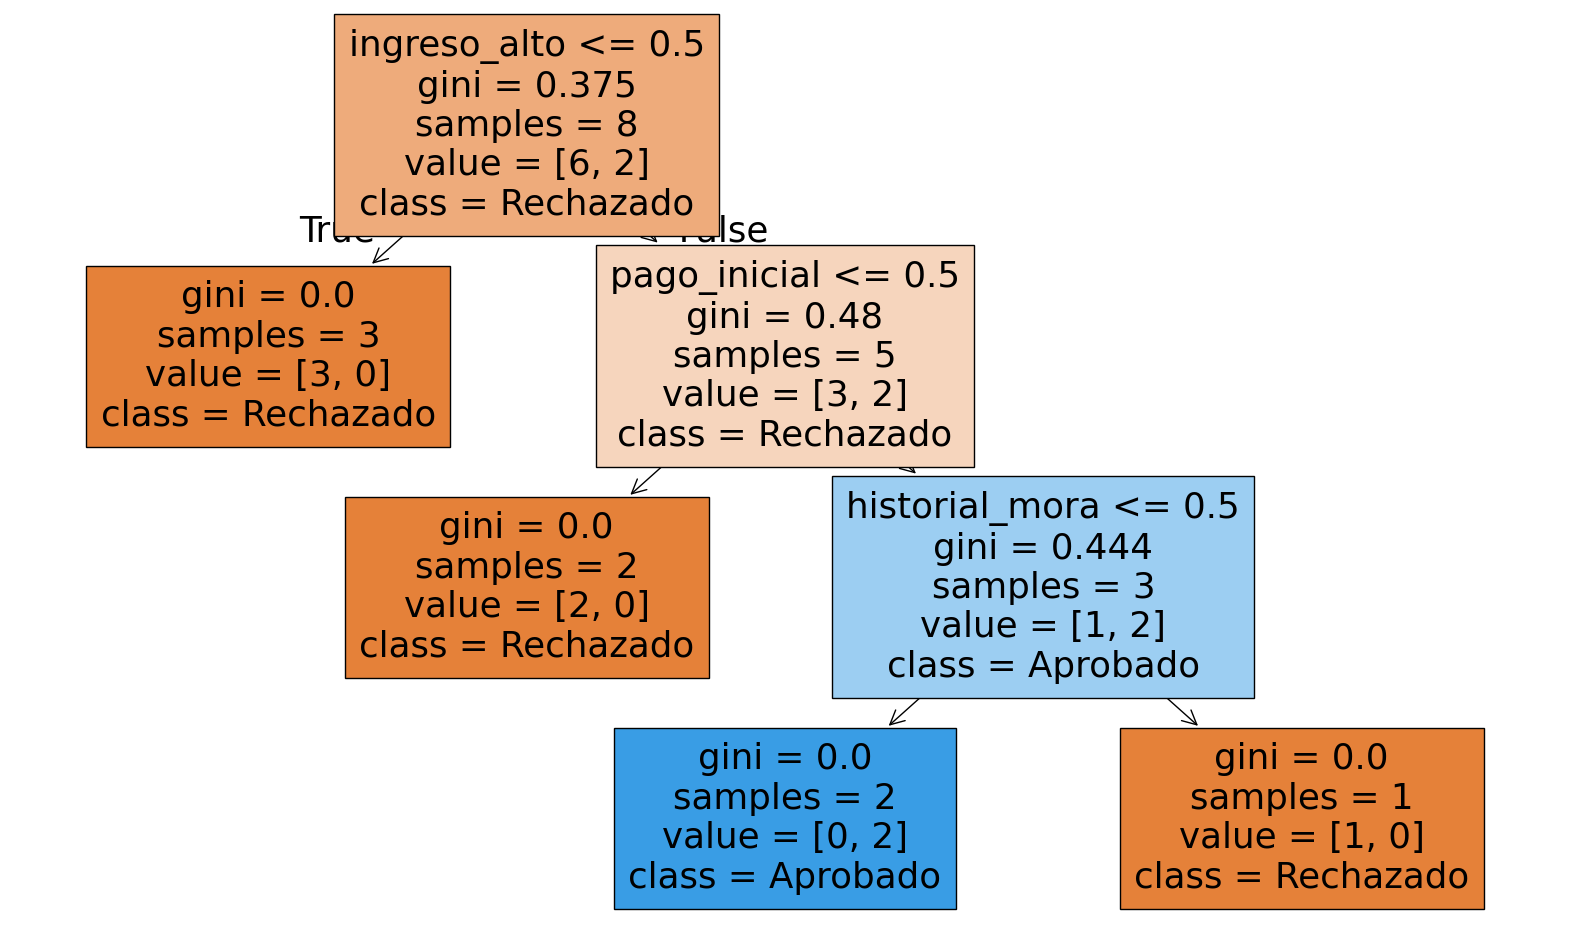

Resultado para el cliente nuevo fue : Aprobado


In [18]:
# Ejemplo árbol de decisión para aprbar un préstamo

import pandas as pd                                          # pandas: para crear y manejar tablas de datos (DataFrames)
import numpy as np                                           # numpy: para trabajar con números y valores especiales como "nulo"
import matplotlib.pyplot as plt                              # matplotlib: para dibujar el árbol de decisiónfrom sklearn.linear_model import LinearRegression            # modelo de regresión lineal (Ejercicios 1 y 2)
from sklearn.tree import DecisionTreeClassifier, plot_tree   # árbol de decisión + función para dibujarlo (Ejercicio 3)

print("Entorno listo ")                                    # mensaje para confirmar que todo se importó sin errores

#Arbol de decision para aprobar un prestamo
# Creamos la tabla con 8 solicitudes de préstamo ya resueltas
prestamos = pd.DataFrame({
    "pago_inicial":   [1, 0, 1, 1, 0, 1, 0, 1],  # 1 = sí entregó pago inicial, 0 = no entregó
    "ingreso_alto":   [1, 1, 0, 1, 0, 1, 1, 0],  # 1 = ingreso mensual mayor a $1,000, 0 = no
    "historial_mora": [0, 0, 0, 1, 1, 0, 0, 1],  # 1 = tiene historial de mora, 0 = no tiene
    "aprobado":       [1, 0, 0, 0, 0, 1, 0, 0],  # 1 = el préstamo fue aprobado, 0 = fue rechazado
})

prestamos  # mostramos la tabla para revisar los datos

# Separamos X (las pistas) e y (lo que queremos predecir)
X = prestamos[["pago_inicial", "ingreso_alto", "historial_mora"]]  # tres columnas de pistas
y = prestamos["aprobado"]                                            # la columna que queremos predecir

# Creamos el árbol de decisión, limitado a una profundidad de 3 preguntas como máximo
arbol = DecisionTreeClassifier(max_depth=3, random_state=42)  # random_state fija el resultado para que siempre sea igual

# Entrenamos el árbol: aquí decide qué preguntas hacer y en qué orden
arbol.fit(X, y)

print("Árbol entrenado ")

#Dibujamos el arbol para ver que preguntas aprendio a hacer
plt.figure(figsize=(20, 12))
plot_tree(
    arbol,                                 #el arbol ya entrenado
    feature_names=X.columns,               #nombres de las colunmas
    class_names=["Rechazado", "Aprobado"], #nombres de las dos categorias
    filled=True)                           #colores para cada caja
plt.show()                                 #mostramos el arbol

#Probamos con un cliente nuevo si pago inicial, si tiene ingreso alto, sin historal de mora
cliente_nuevo = pd.DataFrame({"pago_inicial":[1], "ingreso_alto": [1], "historial_mora": [0]}) #mismos nombres que x
prediccion = arbol.predict(cliente_nuevo)  #el arbol recorre sus preguntas y da una respuesta

resultado = "Aprobado" if prediccion[0] == 1 else "Rechazado" #traducimos el 1/0 a una palabra
print(f"Resultado para el cliente nuevo fue : {resultado}")


In [ ]:
# Ejemplo árbol de decisión para aprbar un préstamo con boton de carga
# cuando tenemos un boton de carga, no necesitamos crear el DataFrame ni usar el cliente nuevo/ solo
#para el inicio, cuando queremos probar el arbol y los resultados


# Ejemplo árbol de decisión para aprobar un préstamo con carga de archivo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from google.colab import files            # Módulo de Colab para subir/descargar archivos
import io                                 # Permite tratar los bytes del archivo subido en memoria

print("Entorno Listo")

# Botón para cargar el archivo
print("Selecciona tu archivo de datos (Excel o CSV):")
subido = files.upload()

# Obtenemos el nombre del archivo seleccionado de forma correcta
nombre_archivo = list(subido.keys())[0]

# Validamos la extensión para leerlo
if nombre_archivo.endswith('.xlsx') or nombre_archivo.endswith('.xls'):
    prestamos = pd.read_excel(io.BytesIO(subido[nombre_archivo]))
else:
    prestamos = pd.read_csv(io.BytesIO(subido[nombre_archivo]))


print(f"\nArchivo '{nombre_archivo}' cargado correctamente.")


# Separamos X (LAS PISTAS) e y (lo que queremos predecir) usando el archivo cargado
X = prestamos[["pago_inicial", "ingreso_alto", "historial_mora"]] # 3 columnas de las pistas [1]
y = prestamos["aprobado"]                                         # la columna que queremos predecir [1]

# Creamos el árbol de decisión limitando a una profundidad de 3 preguntas como máximo
arbol = DecisionTreeClassifier(max_depth=3, random_state=42)

# Entrenamos el modelo con los datos del archivo subido
arbol.fit(X, y)
print("Árbol entrenado")

# Calculamos las predicciones para todo el archivo
predicciones = arbol.predict(X)

# Agregamos los resultados como una nueva columna al archivo para comparar
prestamos["prediccion_arbol"] = predicciones

#Convertimos los números (0 y 1) de la predicción en texto legible
prestamos["resultado_texto"] = prestamos["prediccion_arbol"].apply(lambda x: "Aprobado" if x == 1 else "Rechazado")

# Configuración para que Pandas muestre TODAS las filas en pantalla
pd.set_option('display.max_rows', None)

print("\n*** Predicciones finales para cliente nuevo *** ")
# Imprime la tabla completa e
print(prestamos[["pago_inicial", "ingreso_alto", "historial_mora", "aprobado", "resultado_texto"]])



In [ ]:
#Ejemplo de código con boton de carga/ Profe


import pandas as pd                                          # pandas: para crear y manejar tablas de datos (DataFrames)
import numpy as np                                           # numpy: para trabajar con números y valores especiales como "nulo"
import matplotlib.pyplot as plt                              # matplotlib: para dibujar el árbol de decisión
from sklearn.linear_model import LinearRegression            # modelo de regresión lineal (Ejercicios 1 y 2)
from sklearn.tree import DecisionTreeClassifier, plot_tree   # árbol de decisión + función para dibujarlo (Ejercicio 3)
from google.colab import files                               # files: para mostrar el botón de carga en Colab
import io                                                    # io: para leer el archivo subido desde la memoria
import time                                                  # time: para hacer pausas en el programa

print("Entorno listo ")                                    # mensaje para confirmar que todo se importó sin errores

#Arbol de decision para aprobar un prestamo
# Cargamos las solicitudes de préstamo desde el Excel
archivo = files.upload()                                                  # botón "Elegir archivos": selecciona clientes_entrenamiento.xlsx
prestamos = pd.read_excel(io.BytesIO(archivo[list(archivo.keys())[0]]))   # convertimos el Excel en la tabla prestamos

pd.set_option("display.max_rows", None)   # le decimos a pandas que muestre todas las filas, sin recortar
display(prestamos)                         # mostramos la tabla completa para revisar los datos

# Separamos X (las pistas) e y (lo que queremos predecir)
X = prestamos[["pago_inicial", "ingreso_alto", "historial_mora"]]  # tres columnas de pistas
y = prestamos["aprobado"]                                            # la columna que queremos predecir

# Creamos el árbol de decisión, limitado a una profundidad de 3 preguntas como máximo
arbol = DecisionTreeClassifier(max_depth=3, random_state=42)  # random_state fija el resultado para que siempre sea igual

# Entrenamos el árbol: aquí decide qué preguntas hacer y en qué orden
arbol.fit(X, y)
time.sleep(10)   # pausa el programa 10 segundos antes de seguir
print("Árbol entrenado ")

#Probamos con un cliente nuevo si pago inicial, si tiene ingreso alto, sin historal de mora
#cliente_nuevo = pd.DataFrame({"pago_inicial":[1], "ingreso_alto": [1], "historial_mora": [0]}) #mismos nombres que x
#prediccion = arbol.predict(cliente_nuevo)  #el arbol recorre sus preguntas y da una respuesta

resultado = "Aprobado" if prediccion[0] == 1 else "Rechazado" #traducimos el 1/0 a una palabra
print(f"Resultado para el cliente nuevo fue : {resultado}")

# Resultado del árbol para cada cliente del Excel
prestamos["prediccion"] = ["Aprobado" if p == 1 else "Rechazado" for p in arbol.predict(X)]  # el árbol evalúa a los 200 clientes
display(prestamos)

In [ ]:
#Ejemplo con gráficos y botón de carga

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from google.colab import files
import time

#time.sleep(10)  # pausa el programa 10 segundos antes de seguir
print("Entorno listo")



#Arbol de decision para que un prestamos sea aproado
#prestamos = pd.DataFrame({
#    "pago_inicial":   [1, 0, 1, 1, 0, 1, 0, 1], # 1= Si se ha entrgado el pago inicial,  0= no se ha entregado
 #   "ingreso_alto":   [1, 1, 0, 1, 0, 1, 1, 0], # 1= ingreso mensual mayor a $1000, 0 = no
#    "historial_mora": [0, 0, 0, 1, 1, 0, 0, 1], # 1= tiene historial de mora, 0 =  no tiene
 #   "aprobado":       [1, 0, 0, 0, 0, 1, 0, 0] # 1= el prestamo fue aprovado, 0 = fue rechazado

#})

# Si se usa el entrenamiento dentro del codigo se trae el entrenamiento y prediccion debajo del dataframe

#Se prueba con un cliente nuevo, si pago inicial, si alto ingreso, sin historial de mora
#cliente_nuevo =  pd.DataFrame({
 #   "pago_inicial":   [1],
 #   "ingreso_alto":   [1],
 #   "historial_mora": [0]
#})

#prediccion = arbol.predict(cliente_nuevo) #El arbol recorre sus preguntas y da una res

#resultado = "Aprobado" if prediccion[0] == 1 else "Rechazado" # Se traduce el 1 y 0 a palabra
#print(f"El cliente nuevo será {resultado}.")


archivo = files.upload()  # Muestra el botón "Elegir archivos"

nombre_archivo = list(archivo.keys())[0]
prestamos = pd.read_excel(nombre_archivo)
pd.set_option("display.max_columns", None)

prestamos  # revisa que las columnas coincidan con las esperadas

# Se separan X(Las pistas) e Y(lo que se quiere predecir)
X =  prestamos[["pago_inicial", "ingreso_alto", "historial_mora"]] # X va en doble corchete porque es una tabla
y = prestamos["aprobado"] # y va en un solo corchete porque es una columna (Una serie) (La columna que se quiere predecir)


# Se crea el arbol de decision limitado a una profundidad de 3 preguntas como maximo(Modelo)
arbol = DecisionTreeClassifier(max_depth=3, random_state=42) #Random_state fija el resultado para que siempre sea el mismo

# Se entrena el modelo: el arbol decide que preguntas hace y en que orden
arbol.fit(X, y)
print("Arbol entrenado.")


# Se predice sobre todas las filas del archivo cargado
columnas_esperadas = ["pago_inicial", "ingreso_alto", "historial_mora"]

predicciones = arbol.predict(prestamos[columnas_esperadas])

# Se traduce cada resultado (1/0) a texto
resultados = []
for prediccion in predicciones:
    if prediccion == 1:
        resultados.append("Aprobado")
    else:
        resultados.append("Rechazado")

prestamos["resultado"] = resultados
prestamos
# Conteo de resultados, en orden fijo para que las barras no cambien de lugar
conteo = prestamos["resultado"].value_counts().reindex(["Aprobado", "Rechazado"])
display(prestamos)  # muestra la tabla completa con la columna "resultado"

print("------------------------------------------------------------------------------")


plt.figure(figsize=(6, 4))
conteo.plot(kind="bar", color=["seagreen", "indianred"])  # colores invertidos
plt.title("Cantidad de préstamos aprobados vs rechazados")
plt.xlabel("Resultado")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)
plt.show()

print("------------------------------------------------------------------------------")

#Se dibuja el arbol para ver que preguntas el arbol ha aprendido a hacer
plt.figure(figsize=(12, 8))
plot_tree(arbol,
          feature_names=columnas_esperadas,
          class_names=["Rechazado", "Aprobado"],
          filled=True)
plt.show()

In [29]:
#Preparación de datos para modelado
#Limpiar tabla de clientes
# Creamos la tabla de clientes ya con 3 problemas tipicos incluidos
clientes = pd.DataFrame ({
    "id": [1, 2, 3, 4, 5],  # identificador de cada cliente
    "edad": [25, 34, np.nan, 25, 300], #np.nan = valor faltante; 300 = valor imposible
    "ingreso": [450000, 520000, 610000, 450000, 700000] # ingreso mensual de cada cliente

})

clientes #mostrar la tabla; el cliente 3 tiene Nan y el cliente 4 es igual al cliente 1

# Paso 1
clientes.isna().sum() #.isna () marca true donde hay un valor nulo/ sum () los cuenta por columna

#PAso 2: Una edad de 300 años tambien es un dato "faltante"
#Por eso lo convertimos en NaN
clientes.loc[clientes["edad"]>100, "edad"] = np.nan #.loc selecciona las filas con edad > 100 y las marca como NaN
clientes # ahora hay dos filas con NaN: la que faltaba y la que era imposible

#Paso 3: Calcular la mediana usando las edades que son validas
mediana_edad = clientes ["edad"].median() # la mediana es un valor atípico
print (f"Mediana de edad (Calcula sin valores faltantes): {mediana_edad}")

#Paso 4 rellenar ambos NaN
clientes["edad"] = clientes ["edad"].fillna(mediana_edad) #reemplaza cualquier NaN
clientes

#Paso 5 eliminar la fila duplicada (misma edad e ingreso que otra fila)
clientes = clientes.drop_duplicates(subset=["edad","ingreso"], keep="first") #conserva solo la primera aparición
clientes #tabla final sin nulos, sin valores imposibles y sin filas duplicadas



Mediana de edad (Calcula sin valores faltantes): 25.0


,id,edad,ingreso
0,1,25.0,450000
1,2,34.0,520000
2,3,25.0,610000
4,5,25.0,700000
